# Mini-Project 5: Taxi Route Revenue, Pricing & Fleet Planner

**Scenario.** A matatu association runs 14-seater vehicles on three routes out of Kampala. It wants to forecast demand,
understand fares and decide how many vehicles to deploy. Data: 10 days of passenger counts (Ntinda from the original
question; Entebbe and Mukono illustrative).

Code: `src/taxi/`: `route.py` (`Route`), `market.py` (`LinearMarket`), `backtest.py` (walk-forward evaluation, α grid
search, weekly simulator), `fleet.py` (`FleetPlan`), `plotting.py`. The forecasters come from the shared
`src/core/forecasting.py`; `LinearTrendForecaster` is the same class used in Project 1.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.core.forecasting import (
    LinearTrendForecaster, MovingAverageForecaster, SeasonalNaiveForecaster,
    SimpleExponentialSmoothingForecaster, walk_forward_forecasts,
)
from src.core.metrics import mae
from src.core.plotting import apply_style
from src.taxi import (
    FleetPlan, LinearCurve, LinearMarket, backtest_route, forecast_next_day, grid_search_alpha,
    simulate_weekly_demand,
)
from src.taxi.data import load_routes
from src.taxi.plotting import plot_backtests, plot_seasonal_comparison

apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
routes = load_routes()

## 1. The `Route` class

In [2]:
for r in routes:
    print(r)
pd.DataFrame([{ "route": r.name, "fare (UGX)": r.fare, "total passengers": r.passengers.sum(),
                "total revenue (UGX)": r.total_revenue(), "mean pax/day": r.statistics().mean,
                "variance": r.statistics().variance, "std dev": r.statistics().stdev,
                "CV": r.statistics().cv} for r in routes]).set_index("route")

Route(name='Kampala-Ntinda', days=10, fare=UGX 2,000)
Route(name='Kampala-Entebbe', days=10, fare=UGX 5,000)
Route(name='Kampala-Mukono', days=10, fare=UGX 3,000)


,fare (UGX),total passengers,total revenue (UGX),mean pax/day,variance,std dev,CV
route,,,,,,,
Kampala-Ntinda,"2,000.00",474.00,"948,000.00",47.40,54.27,7.37,0.16
Kampala-Entebbe,"5,000.00",678.00,"3,390,000.00",67.80,45.07,6.71,0.10
Kampala-Mukono,"3,000.00",520.00,"1,560,000.00",52.00,26.44,5.14,0.10


In [3]:
# Daily revenue table and a hand check.
display(pd.DataFrame({r.name: r.daily_revenue() for r in routes}, index=pd.RangeIndex(1, 11, name="day")).T)
ntinda = routes[0]
print(f"Ntinda total: {ntinda.passengers.sum():.0f} passengers × UGX 2,000 = UGX {ntinda.passengers.sum()*2000:,.0f}"
      f" (class: {ntinda.total_revenue():,.0f})")

day,1,2,3,4,5,6,7,8,9,10
Kampala-Ntinda,"70,000.00","80,000.00","84,000.00","100,000.00","110,000.00","120,000.00","96,000.00","104,000.00","94,000.00","90,000.00"
Kampala-Entebbe,"300,000.00","290,000.00","325,000.00","350,000.00","360,000.00","400,000.00","375,000.00","340,000.00","330,000.00","320,000.00"
Kampala-Mukono,"135,000.00","141,000.00","150,000.00","147,000.00","165,000.00","186,000.00","174,000.00","159,000.00","153,000.00","150,000.00"


Ntinda total: 474 passengers × UGX 2,000 = UGX 948,000 (class: 948,000)


## 2. Supply–demand equilibrium on the Ntinda route

$Q_d = 120 - 0.02P$ and $Q_s = 10 + 0.03P$. Rewriting each as $Q - bP = a$ gives a 2×2 linear system in $(P, Q)$:

$$\begin{bmatrix}0.02 & 1\\ -0.03 & 1\end{bmatrix}\begin{bmatrix}P\\ Q\end{bmatrix} = \begin{bmatrix}120\\ 10\end{bmatrix}.$$

In [4]:
market = LinearMarket(demand=LinearCurve(120.0, -0.02), supply=LinearCurve(10.0, 0.03))
A, b = market.system
print("A =", A.tolist(), " b =", b.tolist())
eq = market.equilibrium()
print(f"Equilibrium (scipy.linalg.solve): P* = UGX {eq.price:,.0f},  Q* = {eq.quantity:.0f} passengers per trip-hour")
print(f"Hand check: 120 - 0.02P = 10 + 0.03P  ->  P = 110/0.05 = {110/0.05:,.0f}, Q = {120 - 0.02*2200:.0f}")

current = 2_000.0
qd, qs = market.demand.quantity(current), market.supply.quantity(current)
print(f"\nAt the current fare UGX {current:,.0f}: Qd = {qd:.0f}, Qs = {qs:.0f}, excess demand = {market.excess_demand(current):.0f} "
      f"({market.excess_demand(current)/qs:.0%} of supply)")

A = [[0.02, 1.0], [-0.03, 1.0]]  b = [120.0, 10.0]
Equilibrium (scipy.linalg.solve): P* = UGX 2,200,  Q* = 76 passengers per trip-hour
Hand check: 120 - 0.02P = 10 + 0.03P  ->  P = 110/0.05 = 2,200, Q = 76

At the current fare UGX 2,000: Qd = 80, Qs = 70, excess demand = 10 (14% of supply)


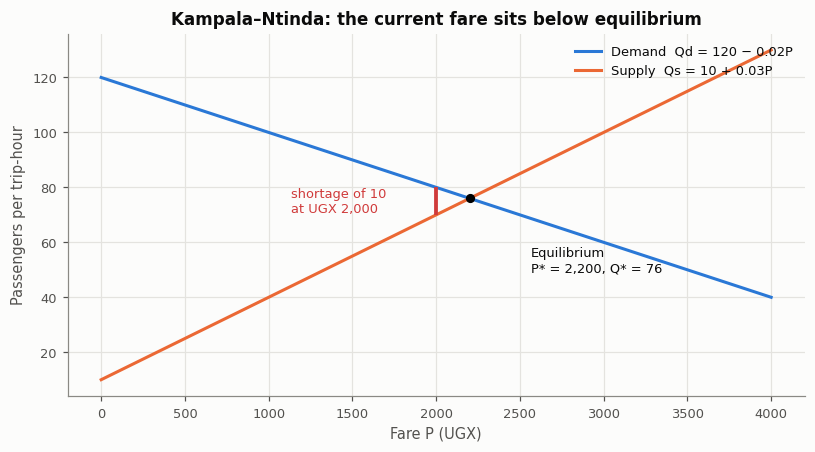

In [5]:
P = np.linspace(0, 4_000, 200)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(P, [market.demand.quantity(p) for p in P], label="Demand  Qd = 120 − 0.02P")
ax.plot(P, [market.supply.quantity(p) for p in P], label="Supply  Qs = 10 + 0.03P")
ax.plot(eq.price, eq.quantity, "ko", zorder=5)
ax.annotate(f"Equilibrium\nP* = {eq.price:,.0f}, Q* = {eq.quantity:.0f}", (eq.price, eq.quantity), xytext=(40, -48),
            textcoords="offset points", fontsize=8.5)
ax.vlines(current, qs, qd, color="#d03b3b", lw=2.5)
ax.annotate(f"shortage of {qd-qs:.0f}\nat UGX {current:,.0f}", (current, (qs+qd)/2), xytext=(-95, 0),
            textcoords="offset points", va="center", fontsize=8.5, color="#d03b3b")
ax.set_xlabel("Fare P (UGX)"); ax.set_ylabel("Passengers per trip-hour")
ax.set_title("Kampala–Ntinda: the current fare sits below equilibrium")
ax.legend(loc="upper right"); fig.tight_layout()
fig.savefig(FIG_DIR / "p5_equilibrium.png", bbox_inches="tight"); plt.show()

**Interpretation** (standard linear market model, e.g. Mankiw, 2021, ch. 4). The equilibrium fare is **UGX 2,200** with 76 passengers per trip-hour. At the current UGX 2,000 the
fare is **UGX 200 (≈ 9 %) below equilibrium**. Passengers want 80 seats per trip-hour but operators supply only 70,
a shortage of 10 (~14 % of supply). That fits what Ntinda commuters see at peak times: queues at the stage, overloading,
and informal "peak surcharges" that effectively move the fare towards equilibrium. Two responses are possible:
* **raise the fare** to ~UGX 2,200, which clears the market by rationing demand; or
* keep the fare and **add supply** (more vehicles or faster turnarounds shift $Q_s$ up), which is the socially
  preferable option if the fare is politically fixed.

A caveat on units: $Q$ is passengers *per trip-hour*, whereas the route data are passengers *per day* (~47). The two
cannot both describe one vehicle's day. The curves presumably describe the whole corridor at peak, so the equilibrium
analysis should be read qualitatively (direction and rough size of the gap), not reconciled number-for-number with
the daily counts.

## 3. Forecasters

All three are subclasses of the abstract `Forecaster` (fit/predict contract):

| Model | Forecast |
|---|---|
| `MovingAverageForecaster(3)` | mean of the last 3 days (the original method) |
| `SimpleExponentialSmoothingForecaster(alpha=None)` (Brown, 1959; Hyndman & Athanasopoulos, 2021, §8.1) | exponentially weighted level; **α is grid-searched inside every fit** over {0.05, …, 1.00} by minimising in-sample one-step squared error |
| `LinearTrendForecaster` | OLS line through all past days, extrapolated |

In [6]:
FACTORIES = [lambda: MovingAverageForecaster(3), lambda: SimpleExponentialSmoothingForecaster(alpha=None),
             LinearTrendForecaster]
MODEL_NAMES = [f().name for f in FACTORIES]
MODEL_NAMES

['3-day moving average', 'SES (tuned α)', 'Linear trend']

## 4. Rolling-origin (walk-forward) backtest over days 4–10

This is the rolling-origin evaluation described by Tashman (2000), also called time-series cross-validation
(Hyndman & Athanasopoulos, 2021, §5.10).

For each day $t = 4,\dots,10$, every model is refitted on days $1..t-1$ only and forecasts day $t$. This gives seven
out-of-sample one-step forecasts per model and route. Revenue is passengers × a fixed fare, so MAE in UGX is
MAE in passengers × fare and the model ranking is identical.

In [7]:
backtests = [backtest_route(r, FACTORIES, first_origin=3) for r in routes]
mae_pax = pd.DataFrame({bt.route.name: bt.mae_passengers() for bt in backtests}).T
mae_ugx = pd.DataFrame({bt.route.name: bt.mae_revenue() for bt in backtests}).T
mae_pax["best"] = mae_pax.idxmin(axis=1)
print("MAE (passengers/day)"); display(mae_pax)
print("MAE (UGX/day)"); display(mae_ugx.style.format("{:,.0f}"))

MAE (passengers/day)


,3-day moving average,SES (tuned α),Linear trend,best
Kampala-Ntinda,7.52,5.87,7.87,SES (tuned α)
Kampala-Entebbe,7.19,5.12,7.71,SES (tuned α)
Kampala-Mukono,5.33,3.76,6.39,SES (tuned α)


MAE (UGX/day)


,3-day moving average,SES (tuned α),Linear trend
Kampala-Ntinda,"15,048","11,735","15,747"
Kampala-Entebbe,"35,952","25,604","38,557"
Kampala-Mukono,"16,000","11,271","19,172"


In [8]:
# Hand check: the first MA(3) forecast for Ntinda (day 4) uses days 1-3 only.
print("MA(3) day-4 forecast for Ntinda:", backtests[0].forecasts["3-day moving average"][0], "=", (35 + 40 + 42) / 3)

# Which alpha did the leak-free SES choose at each origin, and what does a global grid search say?
rows = []
for r in routes:
    chosen = [SimpleExponentialSmoothingForecaster().fit(r.passengers[:t]).alpha_ for t in range(3, 10)]
    best_alpha, scores = grid_search_alpha(r.passengers, first_origin=3)
    rows.append({"route": r.name, "α chosen per origin (days 4–10)": chosen,
                 "global grid-search α": best_alpha, "MAE at global α": scores[best_alpha],
                 "MAE at α=0.3": scores[0.3]})
pd.DataFrame(rows).set_index("route")

MA(3) day-4 forecast for Ntinda: 39.0 = 39.0


,α chosen per origin (days 4–10),global grid-search α,MAE at global α,MAE at α=0.3
route,,,,
Kampala-Ntinda,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.95, 0.95]",1.00,5.86,7.35
Kampala-Entebbe,"[0.05, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]",1.00,4.43,7.03
Kampala-Mukono,"[1.0, 1.0, 0.95, 1.0, 1.0, 1.0, 1.0]",1.00,3.71,4.95


**Reading the backtest.** SES with tuned α wins on all three routes, beating the original 3-day moving average by
roughly a quarter to a third in MAE. The grid search drives α to (or near) **1.0**, i.e. a *naïve* "tomorrow = today"
forecast. The counts behave like a persistent random walk: a busy day tends to be followed by another busy day, and
averaging over three days mixes in stale information. The linear trend is worst: it extrapolates the rise over days 1–6
straight through the turn after day 6.

A note on tuning. A single "global" α chosen by grid search over the *same* days 4–10 that are used for scoring
(right-hand columns) is optimistically biased, because it peeks at the test set. The model we report re-tunes α inside
every fit using only the data available at that origin, so its MAE is an honest out-of-sample number. In this case
both approaches agree on α ≈ 1.

## 5. Day-11 revenue forecast with the best model per route

In [9]:
factory_by_name = dict(zip(MODEL_NAMES, FACTORIES))
next_day = {}
rows = []
for bt in backtests:
    pax, model = forecast_next_day(bt.route, factory_by_name[bt.best_model])
    next_day[bt.route.name] = pax
    rows.append({"route": bt.route.name, "model": bt.best_model,
                 "α (if SES)": getattr(model, "alpha_", np.nan), "day-11 passengers": pax,
                 "day-11 revenue (UGX)": pax * bt.route.fare,
                 "±MAE band (UGX)": f"{(pax - bt.mae_passengers()[bt.best_model]) * bt.route.fare:,.0f} – "
                                     f"{(pax + bt.mae_passengers()[bt.best_model]) * bt.route.fare:,.0f}"})
day11 = pd.DataFrame(rows).set_index("route")
day11

,model,α (if SES),day-11 passengers,day-11 revenue (UGX),±MAE band (UGX)
route,,,,,
Kampala-Ntinda,SES (tuned α),0.95,45.11,"90,224.15","78,490 – 101,959"
Kampala-Entebbe,SES (tuned α),1.00,64.00,"320,000.00","294,396 – 345,604"
Kampala-Mukono,SES (tuned α),1.00,50.00,"150,000.00","138,729 – 161,271"


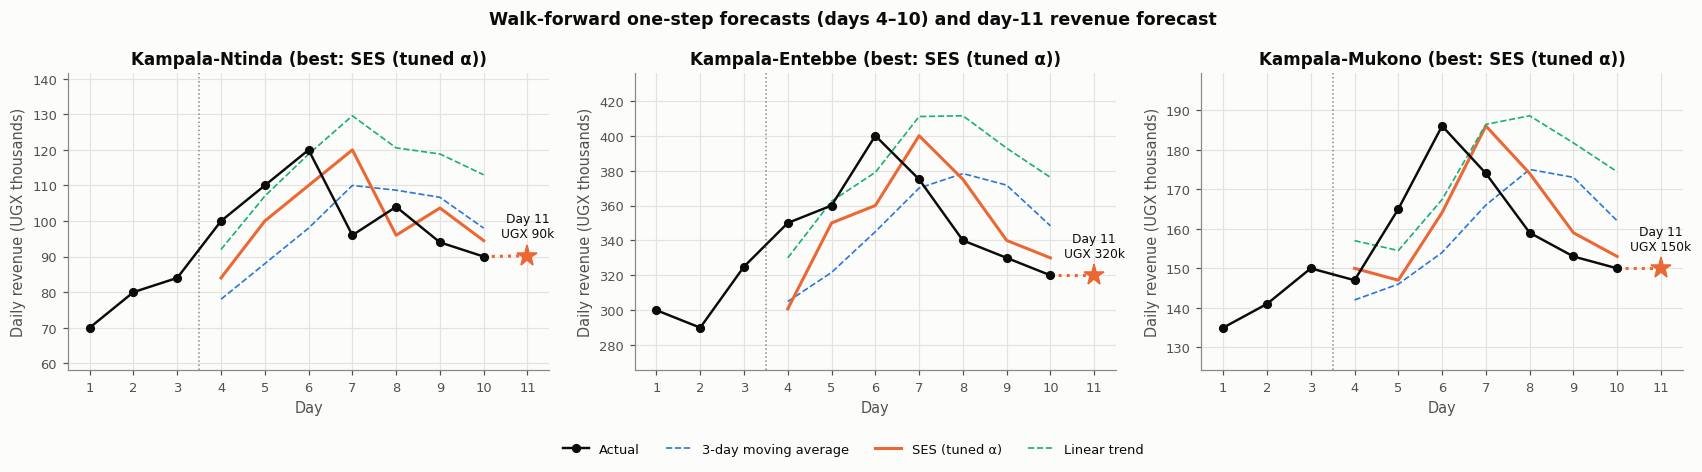

In [10]:
fig = plot_backtests(backtests, {k: v * r.fare for (k, v), r in zip(next_day.items(), routes)}, MODEL_NAMES)
fig.savefig(FIG_DIR / "p5_backtest.png", bbox_inches="tight")
plt.show()

## 6. Fleet planning for day 11

Capacity per vehicle per day = 8 one-way trips × 14 seats = **112 passengers**. Vehicles = ⌈forecast × 1.15 / 112⌉, with
a minimum of one vehicle per operating route. The result is rounded **up** because rounding down would strand exactly
the passengers the 15 % buffer is meant to protect.

In [11]:
plans = [FleetPlan(name, pax) for name, pax in next_day.items()]
pd.DataFrame([{ "route": p.route, "forecast pax": p.forecast_passengers, "with 15% buffer": p.planned_passengers,
                "exact vehicles": p.exact_vehicles, "vehicles to deploy": p.vehicles,
                "expected load factor": p.utilisation} for p in plans]).set_index("route")

,forecast pax,with 15% buffer,exact vehicles,vehicles to deploy,expected load factor
route,,,,,
Kampala-Ntinda,45.11,51.88,0.46,1,0.40
Kampala-Entebbe,64.00,73.60,0.66,1,0.57
Kampala-Mukono,50.00,57.50,0.51,1,0.45


In [12]:
# Sensitivity: what would change the answer? Peak-hour sizing instead of daily averages.
PEAK_SHARE, PEAK_HOURS = 0.40, 3   # assume 40 % of daily riders travel in a 3-hour peak (illustrative)
for p in plans:
    trips_per_peak = 2  # a vehicle can do ~2 one-way trips per peak hour on a short route (assumption)
    peak_capacity = 14 * trips_per_peak * PEAK_HOURS
    need = int(np.ceil(p.forecast_passengers * PEAK_SHARE * 1.15 / peak_capacity))
    print(f"{p.route:>16}: daily sizing {p.vehicles} vehicle(s); peak sizing {max(1, need)} vehicle(s)")

  Kampala-Ntinda: daily sizing 1 vehicle(s); peak sizing 1 vehicle(s)
 Kampala-Entebbe: daily sizing 1 vehicle(s); peak sizing 1 vehicle(s)
  Kampala-Mukono: daily sizing 1 vehicle(s); peak sizing 1 vehicle(s)


**Interpretation.** One vehicle per route has enough *daily* capacity: forecast demand (45–64 passengers) is well
under half of the 112 seats a vehicle offers in eight trips, even after the buffer. The low load factors (40–57 %) are
the more important result. Either the counts cover only part of the day or of the association's fleet, or the routes are
over-served. The binding constraint for matatus is the **peak**, not the daily total. Under an illustrative
peak-hour assumption the answer stays at one vehicle per route. With the given data the association should deploy one
vehicle each and redeploy spare vehicles, while checking whether the passenger counts are complete.

## Extension: weekly seasonality, seasonal-naïve vs moving average

60 days are simulated with a weekly cycle (Friday busiest, Sunday quietest) and Gaussian noise. Each model is then
backtested walk-forward from day 15, after two full weeks of history.

In [13]:
sim = simulate_weekly_demand(60, seed=11)
FIRST = 14
contenders = {"Seasonal naïve (m=7)": SeasonalNaiveForecaster(7), "3-day moving average": MovingAverageForecaster(3),
              "SES (tuned α)": SimpleExponentialSmoothingForecaster()}
fc = {name: walk_forward_forecasts(m, sim, FIRST) for name, m in contenders.items()}
scores = pd.Series({name: mae(sim[FIRST:], f) for name, f in fc.items()}, name="MAE (passengers)").sort_values()
display(scores.to_frame())
weekday_means = pd.Series([sim[d::7].mean() for d in range(7)], index=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
print("Mean passengers by weekday:", weekday_means.round(1).to_dict())

,MAE (passengers)
Seasonal naïve (m=7),2.98
SES (tuned α),6.21
3-day moving average,7.25


Mean passengers by weekday: {'Mon': 49.1, 'Tue': 49.3, 'Wed': 49.9, 'Thu': 51.3, 'Fri': 62.6, 'Sat': 56.8, 'Sun': 33.5}


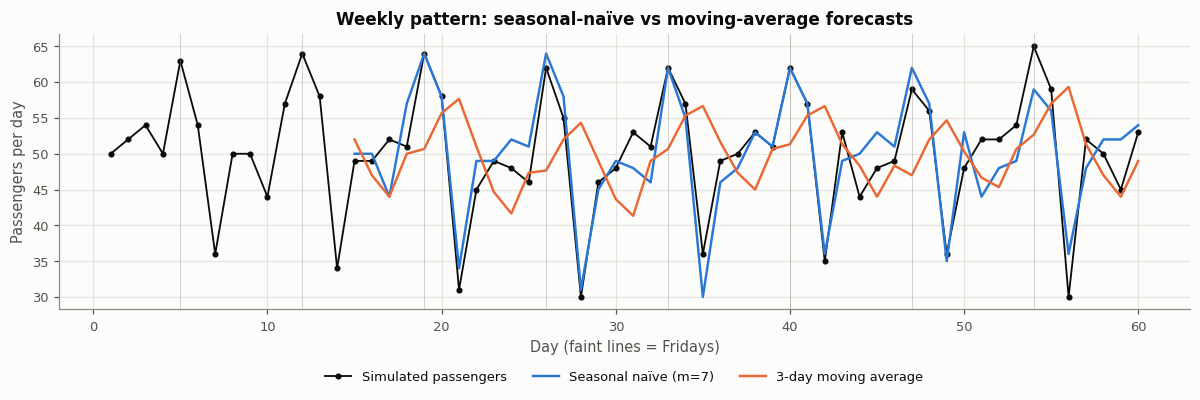

In [14]:
fig = plot_seasonal_comparison(sim, {k: fc[k] for k in ["Seasonal naïve (m=7)", "3-day moving average"]}, FIRST)
fig.savefig(FIG_DIR / "p5_seasonal.png", bbox_inches="tight")
plt.show()

The seasonal-naïve forecaster ("same day last week"; Hyndman & Athanasopoulos, 2021, §5.2) cuts MAE by more than half compared with the 3-day moving
average. The moving average is poorly suited to this pattern: on Friday it averages Tuesday to Thursday and under-forecasts
the peak, and on Sunday it averages the busy Thursday to Saturday and over-forecasts the trough. It **lags the cycle by
about two days**. The seasonal-naïve error is essentially just the noise of two independent days ($\sqrt2\,\sigma$).
With real matatu data, which certainly has weekday effects, a seasonal model (or SES on seasonally adjusted data) should
therefore replace the moving average.

## References

* Brown, R. G. (1959). *Statistical Forecasting for Inventory Control*. McGraw-Hill.
* Hyndman, R. J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts. https://otexts.com/fpp3/
* Hyndman, R. J. & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, 22(4), 679–688.
* Mankiw, N. G. (2021). *Principles of Economics* (9th ed.). Cengage.
* Tashman, L. J. (2000). Out-of-sample tests of forecasting accuracy: an analysis and review. *International Journal of Forecasting*, 16(4), 437–450.

## Findings & Limitations

**Findings.** All routes are stable (passenger CV 0.10–0.16). On Ntinda, the UGX 2,000 fare is ~9 % below the UGX 2,200 equilibrium, leaving a shortage of about ten
passengers per trip-hour. That argues for adding peak capacity (or a modest fare rise) rather than cutting the fare.

Walk-forward backtesting does not support the original method. The 3-day moving average is beaten on every route by SES with
tuned α, which cuts MAE by 22–30 %. The linear trend is worst because it extrapolates the early rise through the turn
after day 6. Tuning pushes α to ≈ 1, so over ten days the best predictor of tomorrow is today: averaging mainly adds lag.
Forecast day-11 revenue is ~UGX 90k (Ntinda), 320k (Entebbe) and 150k (Mukono), each with a typical error of
UGX 12–26k. Even with a 15 % buffer, one vehicle per route covers the forecast at a 40–57 % load factor. The
association either has spare vehicles to redeploy or its counts are incomplete. The extension shows that when a weekly
cycle exists, a seasonal-naïve model halves the moving average's error, so a seasonal method should become the default
once longer data are collected.

**Limitations.** Seven out-of-sample points cannot establish that the MAE differences are statistically significant.
The data carry no weekday labels, although the day-6 peak is probably a weekly effect. A persistence-type forecast
(α ≈ 1) is fragile to one-off shocks such as rain, strikes or fuel-price changes. The demand and supply curves are
given rather than estimated, and their per-trip-hour units cannot be reconciled with daily counts. Fleet sizing
assumes 8 trips a day regardless of congestion (optimistic for Entebbe) and ignores peak-hour
concentration, turnaround times and breakdowns, which in practice drive matatu fleet needs.